In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("07-2023.csv")

In [7]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,36809099410,2023-07-01 09:01,NaN,00:00:38,NaN,Vladimir Suparto
1,36808975799,2023-07-01 09:02,NaN,01:11:04,NaN,Vladimir Suparto
2,36809652317,2023-07-01 10:13,NaN,00:00:44,NaN,Vladimir Suparto
3,36809437488,2023-07-01 10:14,NaN,00:00:46,NaN,Vladimir Suparto
4,36809803333,2023-07-01 10:34,NaN,NaN,NaN,David Banister


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5551 entries, 0 to 5550
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             5551 non-null   int64  
 1   Activity date         5551 non-null   str    
 2   Call direction        402 non-null    str    
 3   Call duration         4859 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  5551 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 457.4 KB


In [14]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [16]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [18]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5551 entries, 0 to 5550
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         5551 non-null   datetime64[us]
 1   Call direction        402 non-null    str           
 2   Call duration         4859 non-null   str           
 3   Activity assigned to  5551 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 283.9 KB


# Call Count per day

In [20]:
df2 = df1.copy()

In [22]:
df2['date'] = df2['Activity date'].dt.date

In [24]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-07-01 09:01:00,NaN,00:00:38,Vladimir Suparto,2023-07-01
1,2023-07-01 09:02:00,NaN,01:11:04,Vladimir Suparto,2023-07-01
2,2023-07-01 10:13:00,NaN,00:00:44,Vladimir Suparto,2023-07-01
3,2023-07-01 10:14:00,NaN,00:00:46,Vladimir Suparto,2023-07-01
4,2023-07-01 10:34:00,NaN,NaN,David Banister,2023-07-01


In [26]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [28]:
daily_calls.head()

,date,call_count
0,2023-07-01,9
1,2023-07-02,3
2,2023-07-03,398
3,2023-07-04,8
4,2023-07-05,356


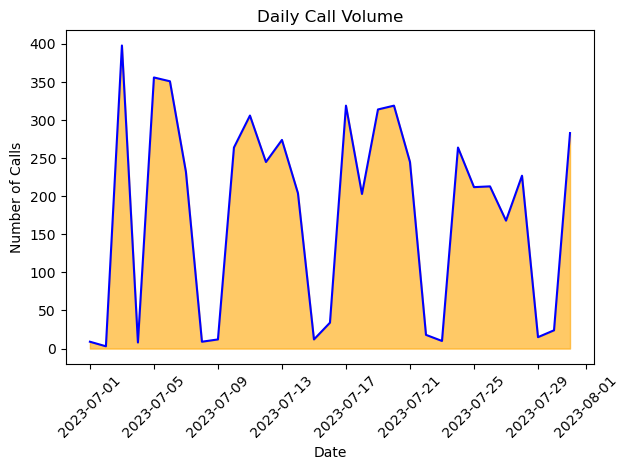

In [30]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

In [35]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-07-01 09:01:00,NaN,00:00:38,Vladimir Suparto,Saturday
1,2023-07-01 09:02:00,NaN,01:11:04,Vladimir Suparto,Saturday
2,2023-07-01 10:13:00,NaN,00:00:44,Vladimir Suparto,Saturday
3,2023-07-01 10:14:00,NaN,00:00:46,Vladimir Suparto,Saturday
4,2023-07-01 10:34:00,NaN,NaN,David Banister,Saturday


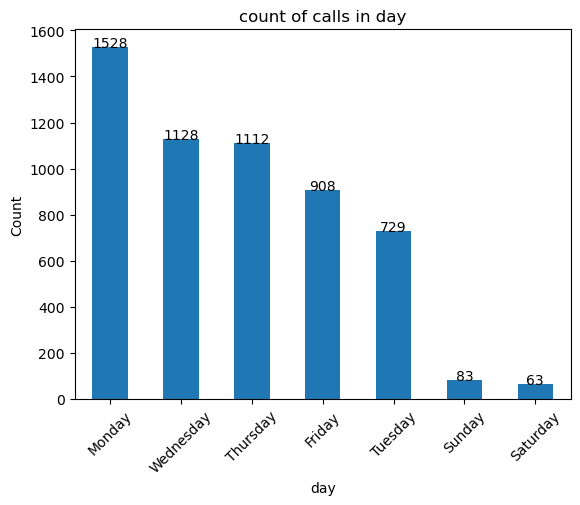

In [37]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

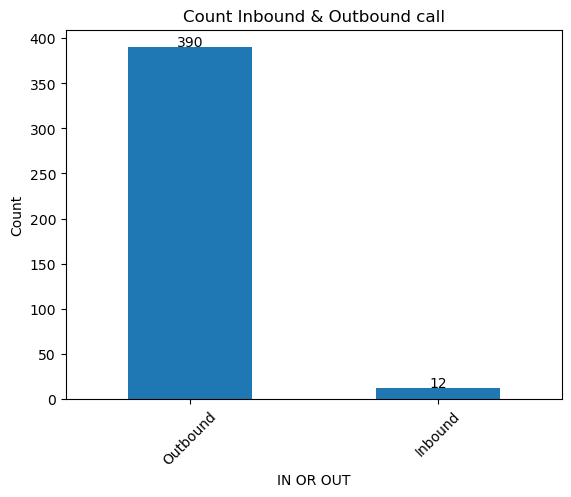

In [40]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [43]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

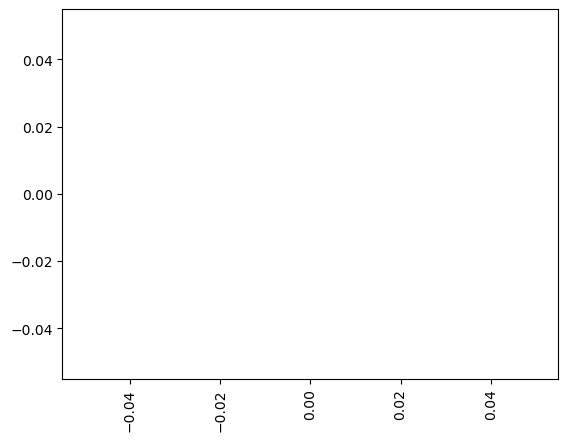

In [45]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call Duration NULL but have Call direction

In [58]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
11,2023-07-02 12:51:00,Outbound,NaN,Keith Antonio,Sunday
18,2023-07-03 09:53:00,Outbound,NaN,Keith Antonio,Monday
19,2023-07-03 09:54:00,Outbound,NaN,Keith Antonio,Monday
507,2023-07-05 13:51:00,Outbound,NaN,Keith Antonio,Wednesday
546,2023-07-05 14:32:00,Outbound,NaN,Jinky Rance,Wednesday
...,...,...,...,...,...
5384,2023-07-31 15:55:00,Outbound,NaN,Robin Stoehr,Monday
5389,2023-07-31 15:59:00,Outbound,NaN,Robin Stoehr,Monday
5390,2023-07-31 16:00:00,Outbound,NaN,Robin Stoehr,Monday
5414,2023-07-31 16:48:00,Inbound,NaN,Robin Stoehr,Monday


In [60]:
df4 = df1.copy()

In [62]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-07-01 09:01:00,NaN,00:00:38,Vladimir Suparto,Saturday
1,2023-07-01 09:02:00,NaN,01:11:04,Vladimir Suparto,Saturday
2,2023-07-01 10:13:00,NaN,00:00:44,Vladimir Suparto,Saturday
3,2023-07-01 10:14:00,NaN,00:00:46,Vladimir Suparto,Saturday
4,2023-07-01 10:34:00,NaN,NaN,David Banister,Saturday


In [64]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [66]:
(df4['Call duration'] == 0).sum()

0

In [68]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [70]:
df4 = df4.dropna(subset = ['Call direction'])

In [72]:
(df4['Call duration'] == 0).sum()

145

In [76]:
df4.info()

<class 'pandas.DataFrame'>
Index: 402 entries, 11 to 5501
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         402 non-null    datetime64[us]
 1   Call direction        402 non-null    str           
 2   Call duration         402 non-null    float64       
 3   Activity assigned to  402 non-null    str           
 4   day                   402 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 29.6 KB


# Working Call Assigner

In [48]:
df1['Activity assigned to'].nunique()

19

In [50]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[   'Vladimir Suparto',      'David Banister',        'David Valdez',
         'Sal Berdayi',        'Karen Parker',       'Keith Antonio',
    'Benjamin Sklivas',        'Ray Levesque',          'Daniel Uli',
        'Dioni Canega',      'Travis Fleming',         'Jinky Rance',
         'Adrian Tran',      'Cameron Dudley',       'Tommie Walker',
 'Demmie Rose Tamonan',         'Paol Guzman',        'Robin Stoehr',
    'Chrystel Manabat']
Length: 19, dtype: str

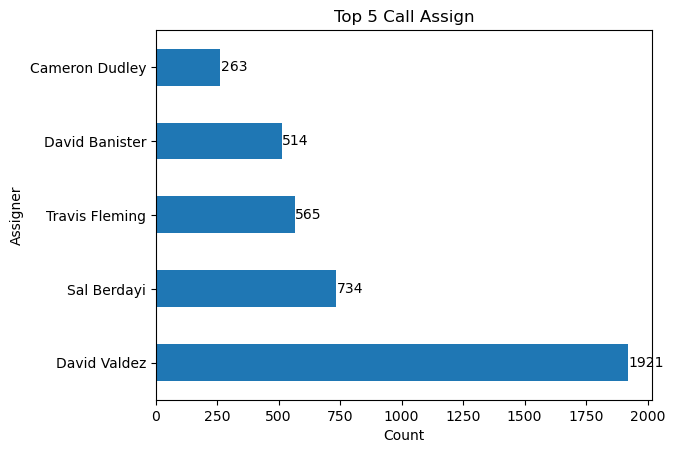

In [52]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [78]:
df4['Call duration'].max()

99.28333333333333

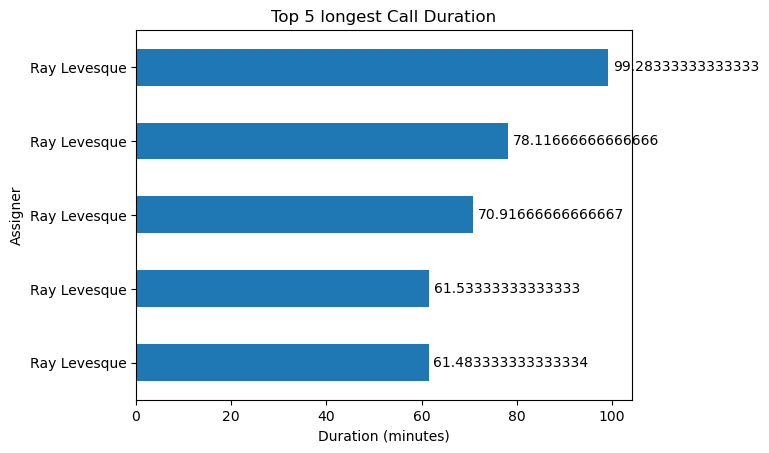

In [80]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [83]:
df3 = df1.copy()

In [85]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [87]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [89]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

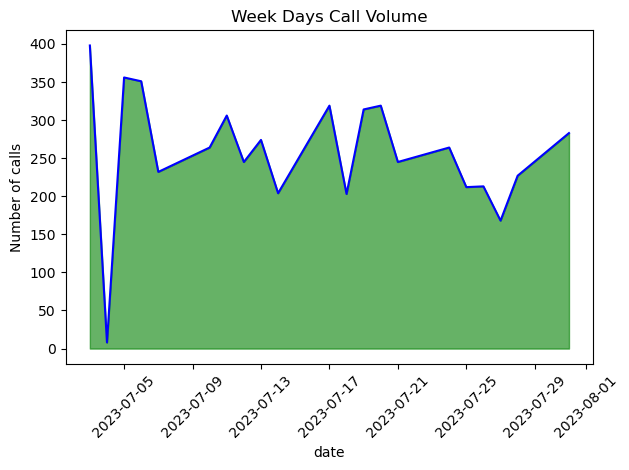

In [91]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [94]:
df5=df4.copy()

In [96]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [98]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
11,2023-07-02 12:51:00,Outbound,0.000000,Keith Antonio,Sunday
1366,2023-07-09 13:00:00,Outbound,20.366667,Keith Antonio,Sunday
1368,2023-07-09 18:31:00,Outbound,0.583333,Keith Antonio,Sunday
1369,2023-07-09 18:33:00,Outbound,0.000000,Keith Antonio,Sunday
2683,2023-07-16 12:00:00,Outbound,1.266667,Keith Antonio,Sunday


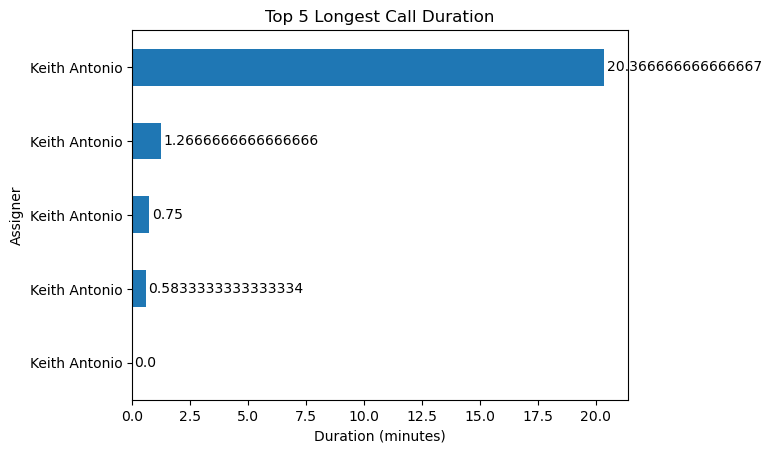

In [100]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

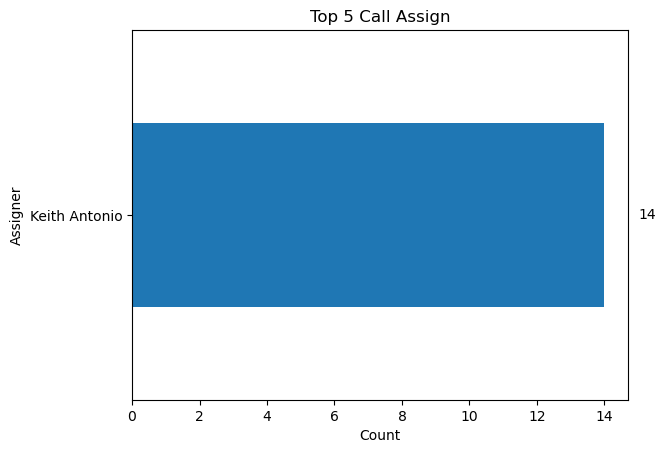

In [103]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [106]:
df4["Call duration"].mean()

4.753855721393036

In [108]:
df4["Call duration"].median()

0.775

# Without Call Assigner Calls

In [111]:
df6 = df3.copy()

In [113]:
df6['month'] = df6['Activity date'].dt.month_name()

In [115]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

IndexError: index 0 is out of bounds for axis 0 with size 0

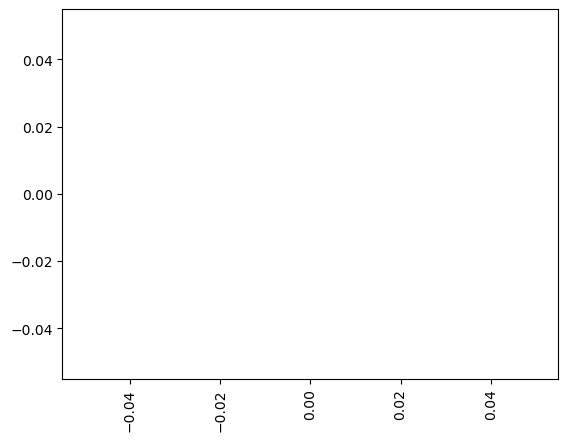

In [117]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call date

In [120]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [122]:
top5 = daily_calls.sort_values(ascending=False).head(5)

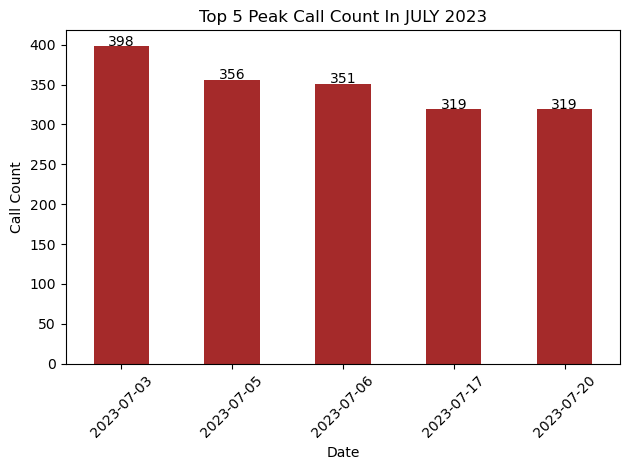

In [126]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JULY 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()